In [70]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

Create a CNN to classify the images

In [ ]:
transformer = transforms.Compose([
    transforms.ToTensor(), # convert PIL image to PyTorch tensor and scale pixel values to [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # normalize the pixel values to have mean 0 and std 1
    # If a pixel is 0 (minimum): (0 - 0.5) / 0.5 = -1
    # If a pixel is 1 (maximum): (1 - 0.5) / 0.5 = 1
])

data_train = datasets.CIFAR10(root='data', train=True, download=True, transform=transformer) 
data_test = datasets.CIFAR10(root='data', train=False, download=True, transform=transformer)    

# ToTensor(): This transform is lazy. It doesn't overwrite the original data in memory. 
# Instead, it only applies the conversion and scaling (-1 to 1) when the data is actually loaded (usually via a DataLoader or by indexing the dataset).
data_train.data.max()

np.uint8(255)

In [72]:
print(data_train.classes) # check the class names, there are 10 classes in total

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6862745..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.94509804].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.88235295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..1.0].
Clipping input da

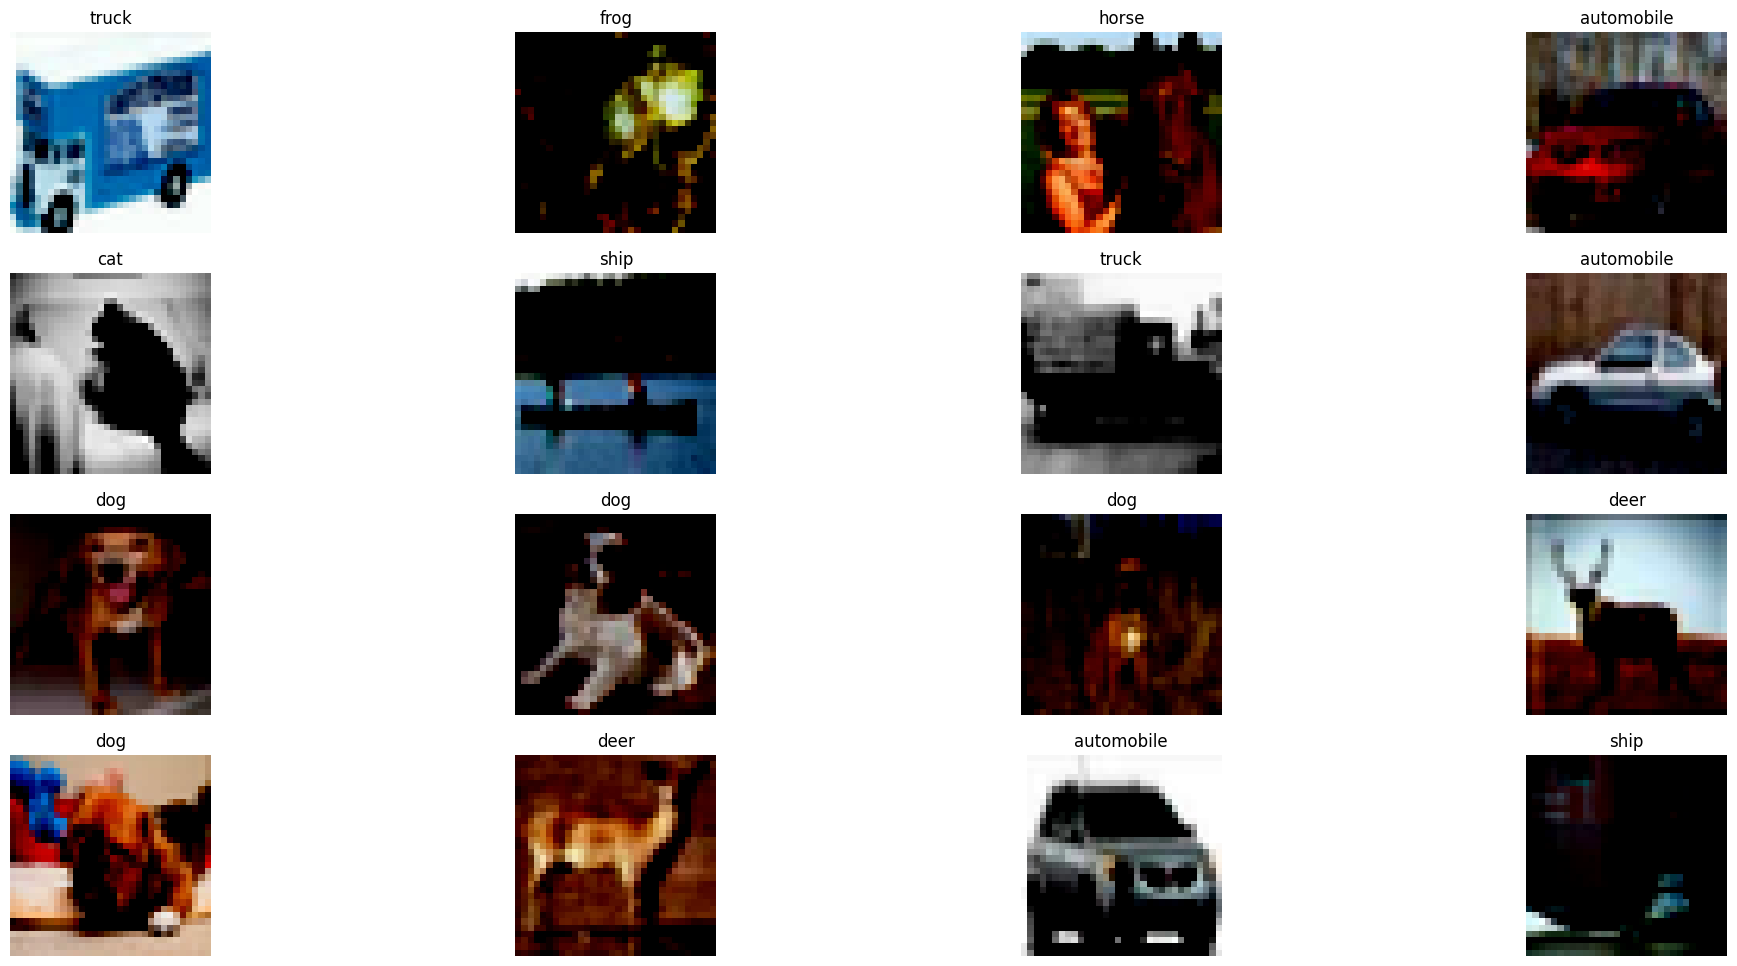

In [73]:
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(25, 12))

for ax in ax.flatten():
    random_index = np.random.randint(0, len(data_train))
    image, label = data_train[random_index]
    label = data_train.classes[data_train.targets[random_index]]
    ax.imshow(image.permute(1, 2, 0), label=label, cmap='gray') # permute(1, 2, 0) changes the order of dimensions from (C, H, W) to (H, W, C) for displaying the image correctly
    ax.set_title(label)
    ax.axis("off")

In [74]:
data_val, data_test = train_test_split(data_test, test_size=0.5, random_state=42) # split the original test set into validation and test sets (50% each)

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
val_dataloader = DataLoader(data_val, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

# check out a sample
images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
images.min(), images.max() # check the range of pixel values (should be between -1 and 1 due to normalization)

Image batch shape: torch.Size([32, 3, 32, 32])
Label batch shape: torch.Size([32])


(tensor(-1.), tensor(1.))

In [ ]:
class CIFAR10_CNN(nn.Module):
    def __init__(self, num_channels=(4, 8, 16)):
        super().__init__()
        # With k=3, padding=1, stride = 1, we came with size_in = size_out
        self.encoder = nn.Sequential(
            # input size = (3, 32, 32) for CIFAR-10
            nn.Conv2d(in_channels=3, out_channels=num_channels[0], kernel_size=3, stride=1, padding=1), # output size = np.floor((32 - 3 + 2*1) / 1) + 1 = 32
            # the input to batch normalization is the output of the convolutional layer, which has 6 channels (out_channels=6), even though it is called "num_features", it actually refers to the number of channels in the output of the convolutional layer
            nn.BatchNorm2d(num_features=num_channels[0]), # this is used to normalize the output of the convolutional layer, which can help with training stability and convergence
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size = np.floor((32 - 2) / 2) + 1 = 16

            nn.Conv2d(in_channels=num_channels[0], out_channels=num_channels[1], kernel_size=3, stride=1, padding=1), # output size = np.floor((16 - 3 + 2*1) / 1) + 1 = 16
            nn.BatchNorm2d(num_features=num_channels[1]), 
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size  = np.floor((16 - 2) / 2) + 1 = 8

            nn.Conv2d(in_channels=num_channels[1], out_channels=num_channels[2], kernel_size=3, stride=1, padding=1), # output size = np.floor((8 - 3 + 2*1) / 1) + 1 = 8
            nn.BatchNorm2d(num_features=num_channels[2]), 
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size  = np.floor((8 - 2) / 2) + 1 = 4
        )

        self.fnn = nn.Sequential(
            nn.Flatten(), # flatten the output of the convolutional layers to feed into the fully connected layers
            nn.Linear(in_features=num_channels[2]*4*4, out_features=256),
            nn.LeakyReLU(),
            nn.Dropout(0.5), # add dropout to prevent overfitting
            nn.Linear(in_features=256, out_features=64),
            nn.LeakyReLU(),
            nn.Dropout(0.5), # add dropout to prevent overfitting
            nn.Linear(in_features=64, out_features=10) # 10 classes for CIFAR-10
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.fnn(x)
        
        return x
    
model = CIFAR10_CNN(num_channels=(64, 128, 256))
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
         LeakyReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5          [-1, 128, 16, 16]          73,856
       BatchNorm2d-6          [-1, 128, 16, 16]             256
         LeakyReLU-7          [-1, 128, 16, 16]               0
         MaxPool2d-8            [-1, 128, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         295,168
      BatchNorm2d-10            [-1, 256, 8, 8]             512
        LeakyReLU-11            [-1, 256, 8, 8]               0
        MaxPool2d-12            [-1, 256, 4, 4]               0
          Flatten-13                 [-1, 4096]               0
           Linear-14                  [

In [76]:
# test one forward pass to see the print statements in action
model = CIFAR10_CNN(num_channels=(4, 8, 16))
loss_fn = nn.CrossEntropyLoss() # it implements both softmax and the negative log-likelihood loss
images, labels = next(iter(train_dataloader))
output = model(images)
predicted_classes = output.argmax(dim=1)
loss = loss_fn(output, labels)
print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Loss: {loss.item()}")

Input shape: torch.Size([32, 3, 32, 32])
Output shape: torch.Size([32, 10])
Labels shape: torch.Size([32])
Loss: 2.317725419998169


In [77]:
def train_one_epoch(model: torch.nn.Module,
                    train_dataloader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    ):
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        # Forward pass
        outputs = model(X)
        loss = loss_fn(outputs, y)

        # Update training loss and accuracy
        train_loss += loss.item()
        train_accuracy += (outputs.argmax(dim=1) == y).sum().item() # count the number of correct predictions

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          ):

    train_losses_epochs = []
    val_losses_epochs = []
    train_accuracy_epochs = []
    val_accuracy_epochs = []

    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_dataloader, loss_fn, optimizer)

        # Calculate average training loss and accuracy for the epoch
        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_accuracy = train_accuracy / len(train_dataloader.dataset)
        train_losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_accuracy)

        # Evaluate on the validation set
        model.eval()
        val_loss = 0.0
        val_accuracy = 0.0

        with torch.no_grad():
            for X, y in val_dataloader:
                outputs = model(X)
                loss = loss_fn(outputs, y)

                val_loss += loss.item()
                val_accuracy += (outputs.argmax(dim=1) == y).sum().item()

        avg_val_loss = val_loss / len(val_dataloader)
        avg_val_accuracy = val_accuracy / len(val_dataloader.dataset)
        val_losses_epochs.append(avg_val_loss)
        val_accuracy_epochs.append(avg_val_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {avg_train_loss:.4f}, "
            f"Val Loss: {avg_val_loss:.4f}, "
            f"Train Accuracy: {avg_train_accuracy:.4f}, "
            f"Val Accuracy: {avg_val_accuracy:.4f}"
        )

    return train_losses_epochs, val_losses_epochs, train_accuracy_epochs, val_accuracy_epochs

In [ ]:
loss_fn = nn.CrossEntropyLoss()
epochs = 15

model = CIFAR10_CNN(num_channels=(16, 32, 64))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
train_loss, val_loss, train_accuracy, val_accuracy = train(model, train_dataloader, val_dataloader, loss_fn, optimizer, epochs)

Epoch [1/15], Train Loss: 1.5730, Val Loss: 1.2428, Train Accuracy: 0.4159, Val Accuracy: 0.5394
Epoch [2/15], Train Loss: 1.2409, Val Loss: 0.9854, Train Accuracy: 0.5600, Val Accuracy: 0.6590
Epoch [3/15], Train Loss: 1.0943, Val Loss: 0.9305, Train Accuracy: 0.6178, Val Accuracy: 0.6670
Epoch [4/15], Train Loss: 0.9921, Val Loss: 0.8719, Train Accuracy: 0.6629, Val Accuracy: 0.6978
Epoch [5/15], Train Loss: 0.9226, Val Loss: 0.7901, Train Accuracy: 0.6886, Val Accuracy: 0.7348
Epoch [6/15], Train Loss: 0.8581, Val Loss: 0.7807, Train Accuracy: 0.7122, Val Accuracy: 0.7322
Epoch [7/15], Train Loss: 0.8190, Val Loss: 0.7939, Train Accuracy: 0.7246, Val Accuracy: 0.7262
Epoch [8/15], Train Loss: 0.7704, Val Loss: 0.7362, Train Accuracy: 0.7424, Val Accuracy: 0.7472
Epoch [9/15], Train Loss: 0.7399, Val Loss: 0.7319, Train Accuracy: 0.7518, Val Accuracy: 0.7500
Epoch [10/15], Train Loss: 0.7028, Val Loss: 0.7355, Train Accuracy: 0.7641, Val Accuracy: 0.7508
Epoch [11/15], Train Loss: 0.

In [80]:
# get the final test accuracy
model.eval()
test_loss = 0.0
test_accuracy = 0.0
with torch.no_grad():
    for X, y in test_dataloader:
        outputs = model(X)
        loss = loss_fn(outputs, y)

        test_loss += loss.item()
        test_accuracy += (outputs.argmax(dim=1) == y).sum().item()

# calculate the average test loss and accuracy
test_loss /= len(test_dataloader)
test_accuracy /= len(test_dataloader.dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.7242
Test Accuracy: 0.7762


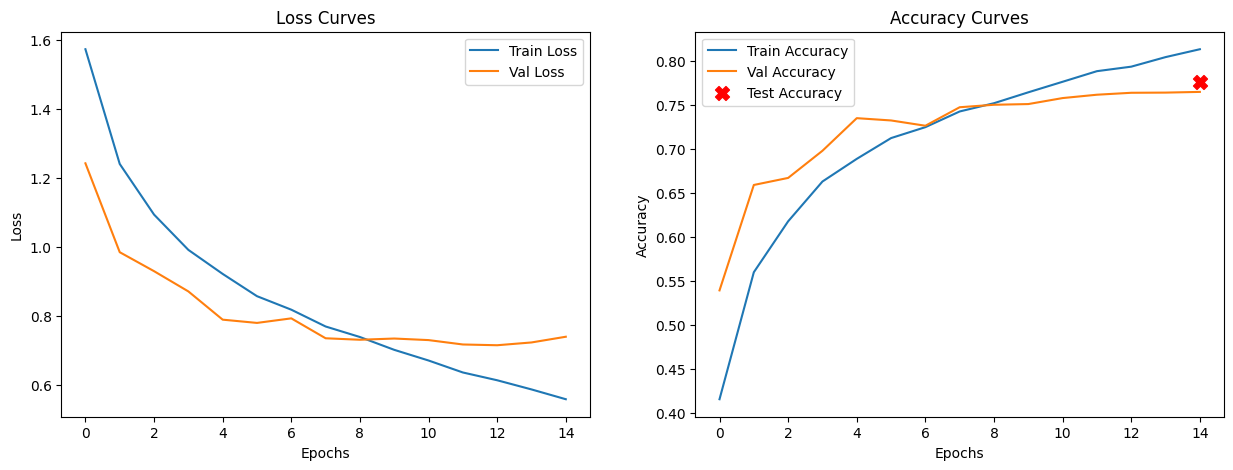

In [ ]:
# plot loss and accuracy curves
plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label="Train Accuracy")
plt.plot(val_accuracy, label="Val Accuracy")
plt.scatter(epochs-1, test_accuracy, label="Test Accuracy", color="red", marker="X", s=100)
plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# there is a small overfitting, so this means, we could have stopped training earlier, but we trained for 15 epochs to see the curves more clearly. 
# We could also add more regularization (e.g. dropout, weight decay) to reduce overfitting.